<a href="https://colab.research.google.com/github/pranavkerkar31/Facial-Expression-Recognition/blob/main/trainmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the required LIbraries

In [2]:
pip install tensorflow keras keras-preprocessing pandas numpy pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.3 MB/s eta 0:00:00


In [3]:

from keras.utils import to_categorical
from keras_preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
import os
import pandas as pd
import numpy as np

Download the dataset

In [4]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d jonathanoheix/face-expression-recognition-dataset
!unzip face-expression-recognition-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/validation/fear/8797.jpg  
  inflating: images/validation/fear/8818.jpg  
  inflating: images/validation/fear/886.jpg  
  inflating: images/validation/fear/9037.jpg  
  inflating: images/validation/fear/9040.jpg  
  inflating: images/validation/fear/9101.jpg  
  inflating: images/validation/fear/911.jpg  
  inflating: images/validation/fear/9179.jpg  
  inflating: images/validation/fear/9205.jpg  
  inflating: images/validation/fear/9232.jpg  
  inflating: images/validation/fear/9251.jpg  
  inflating: images/validation/fear/9261.jpg  
  inflating: images/validation/fear/9281.jpg  
  inflating: images/validation/fear/9302.jpg  
  inflating: images/validation/fear/9333.jpg  
  inflating: images/validation/fear/9369.jpg  
  inflating: images/validation/fear/9370.jpg  
  inflating: images/validation/fear/9474.jpg  
  inflating: images/validation/fear/949.jpg  
  inflating: images/validation/fear/9602.jpg  
  inflating:

Set the folder path

In [5]:
TRAIN_DIR = 'images/train'
TEST_DIR = 'images/validation'

Print the train and the test as DataFrame

In [6]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label, "completed")
    return image_paths,labels


In [7]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

angry completed
disgust completed
surprise completed
fear completed
neutral completed
happy completed
sad completed


In [8]:
print(train)

                              image  label
0       images/train/angry/6912.jpg  angry
1      images/train/angry/13442.jpg  angry
2      images/train/angry/10947.jpg  angry
3      images/train/angry/20942.jpg  angry
4      images/train/angry/12783.jpg  angry
...                             ...    ...
28816     images/train/sad/2175.jpg    sad
28817    images/train/sad/16384.jpg    sad
28818    images/train/sad/32987.jpg    sad
28819    images/train/sad/30810.jpg    sad
28820    images/train/sad/23720.jpg    sad

[28821 rows x 2 columns]


In [9]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

angry completed
disgust completed
surprise completed
fear completed
neutral completed
happy completed
sad completed


In [10]:
print(test)
print(test['image'])

                                  image  label
0     images/validation/angry/29527.jpg  angry
1     images/validation/angry/19950.jpg  angry
2      images/validation/angry/7492.jpg  angry
3     images/validation/angry/18376.jpg  angry
4     images/validation/angry/12851.jpg  angry
...                                 ...    ...
7061     images/validation/sad/9769.jpg    sad
7062    images/validation/sad/30358.jpg    sad
7063     images/validation/sad/8266.jpg    sad
7064    images/validation/sad/33152.jpg    sad
7065      images/validation/sad/422.jpg    sad

[7066 rows x 2 columns]
0       images/validation/angry/29527.jpg
1       images/validation/angry/19950.jpg
2        images/validation/angry/7492.jpg
3       images/validation/angry/18376.jpg
4       images/validation/angry/12851.jpg
                      ...                
7061       images/validation/sad/9769.jpg
7062      images/validation/sad/30358.jpg
7063       images/validation/sad/8266.jpg
7064      images/validation/sad/3

In [11]:
from tqdm.notebook import tqdm

Convert the images to Grayscale

In [12]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image,grayscale =  True )
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features),48,48,1)
    return features


In [13]:
train_features = extract_features(train['image'])

  0%|          | 0/28821 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/keras_preprocessing/image/utils.py:107: UserWarning: grayscale is deprecated. Please use color_mode = "grayscale"
  warnings.warn('grayscale is deprecated. Please use '


In [14]:
test_features = extract_features(test['image'])

  0%|          | 0/7066 [00:00<?, ?it/s]

In [15]:
x_train = train_features/255.0
x_test = test_features/255.0

Give the classes numbers like 0,1,2....

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [18]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [19]:
y_train = to_categorical(y_train,num_classes = 7)
y_test = to_categorical(y_test,num_classes = 7)

CNN Model Architecture

In [20]:
model = Sequential()
# convolutional layers
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
# fully connected layers
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
# output layer
model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Optimizer

In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train the Model

In [22]:
model.fit(x= x_train,y = y_train, batch_size = 128, epochs = 50, validation_data = (x_test,y_test))

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.2441 - loss: 1.8266 - val_accuracy: 0.2583 - val_loss: 1.8106
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.2554 - loss: 1.7940 - val_accuracy: 0.3019 - val_loss: 1.7183
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.3091 - loss: 1.6967 - val_accuracy: 0.3712 - val_loss: 1.6108
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.3860 - loss: 1.5578 - val_accuracy: 0.4587 - val_loss: 1.4175
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.4309 - loss: 1.4695 - val_accuracy: 0.4737 - val_loss: 1.3694
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.4494 - loss: 1.4209 - val_accuracy: 0.4841 - val_loss: 1.3323
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.4699 - loss: 1.3790 - val_accuracy: 0.5164 - val_loss: 1.2701
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.4825 - loss: 1.3508 - 

In [23]:
model_json = model.to_json()

with open("emotiondetector.json", "w") as json_file:
    json_file.write(model_json)

model.save("emotiondetector.h5")

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Emotion labels
label = ["angry","disgust","fear","happy","neutral","sad","surprise"]

# Predictions
y_prob = model.predict(x_test)
y_pred = y_prob.argmax(axis=1)
y_true = y_test.argmax(axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("\n===== Evaluation Metrics =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\n===== Confusion Matrix =====")
print(cm)

221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

===== Evaluation Metrics =====
Accuracy  : 0.6156
Precision : 0.5983
Recall    : 0.5747
F1 Score  : 0.5818

===== Confusion Matrix =====
[[ 467   17   91   75  137  141   32]
 [  21   53   14    6    4   10    3]
 [ 116    5  341   75  121  234  126]
 [  32    0   34 1584   66   80   29]
 [  86    2   49  147  704  196   32]
 [ 105    5   97   78  219  610   25]
 [   9    1   79   76   25   16  591]]


In [28]:
from keras.models import model_from_json

In [32]:
json_file = open("emotiondetector.json", "r")
model_json = json_file.read()
json_file.close()
model = model_from_json(model_json)
model.load_weights("emotiondetector.h5")

In [31]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']

In [29]:
def ef(image):
    img = load_img(image,grayscale =  True )
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    return feature/255.0


In [34]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
model prediction is  sad


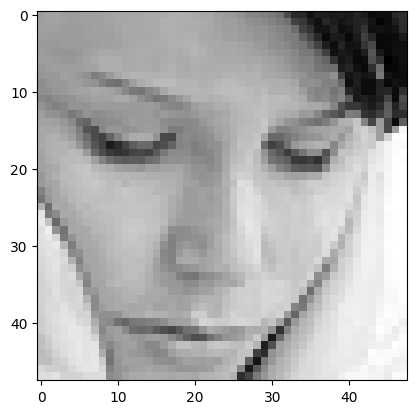

In [35]:
image = 'images/train/sad/42.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
model prediction is  fear


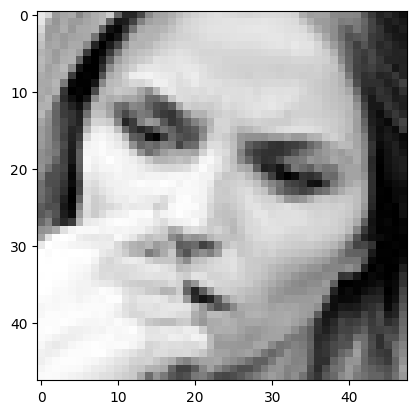

In [36]:
image = 'images/train/fear/2.jpg'
print("original image is of fear")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
model prediction is  disgust


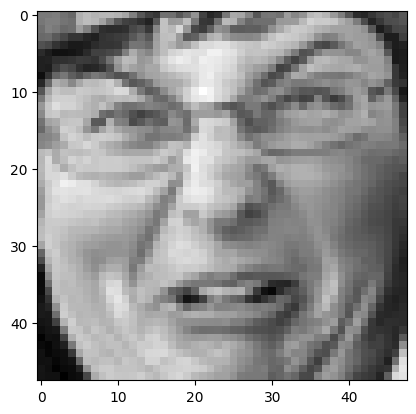

In [37]:
image = 'images/train/disgust/299.jpg'
print("original image is of disgust")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
model prediction is  happy


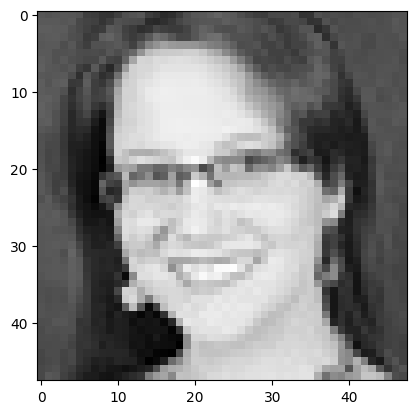

In [ ]:
image = 'images/train/happy/7.jpg'
print("original image is of happy")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
model prediction is  surprise


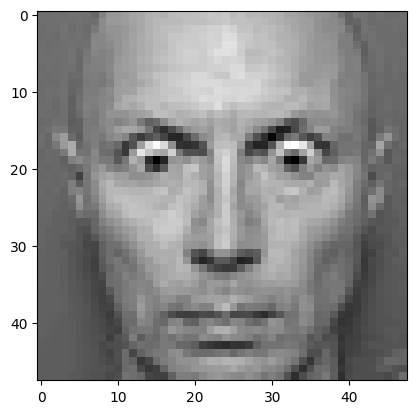

In [ ]:
image = 'images/train/surprise/15.jpg'
print("original image is of surprise")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')